## Your first Neural Network in PyTorch – An Introduction

#### Associated Jupyter Notebook and Code

During the course of this workshop, we will build simple Neural Networks to classify the MNIST dataset of hand-written digits.
On the way, you will learn:
- to read image files in Python and bring them in the same format
- to download and read openly available datasets for training Neural Networks
- the fundamentals of Neural Networks; how do they work?, what components are necessary?, ..
- the fundamentals of Convolutional Neural Networks; why are they good for a lot of image tasks?
- how to use PyTorch to implement a Neural Network
- how PyTorch computes stuff
- if the trained model is able to correctly identifies your handwritten postal code

### First Steps:

#### 1. Create a Python environment for this project 

Our recommendation: use 'uv' to create and manage your environment.
To set up a new environment this way, 
- Create a new folder for your project
- Open the terminal and navigate to this project
- Clone this repository using "git clone https://github.com/BAMeScience/workshop_neural_nets.git" or download the repository by hand and unzip in the new folder
- In the terminal, from your project path, execute "cd workshop_neural_nets" (you are now in the workshop folder)
- Install uv if it is not already installed ("python -m pip install uv")
- Execute "uv sync --locked" (this will create the environment and install all dependencies directly)
- Activate the environment by 'source .venv/bin/activate' (Linux) or '.venv\Scripts\activate' (Windows)
- Once its activated, we can install new packages using 'uv add PACKAGENAME'. All necessary packages for this Workshop should have already been installed auomatically.
- To use Jupyter Notebooks with the workshop kernel, navigate to your workspace folder and run (all in terminal): uv run python -m ipykernel install --user --name workshop --display-name "Python Workshop"

#### 2. Write your postal code digit-by-digit in Paint 

The goal of this workshop is to create a program that can read handwritten images of the German Postal code.

To make pre-processing easier, we save every digit individually as a single image. Please open paint and write every digit of your (or a made up) postal code in an individual file and save it as a .png on your drive.

In [1]:
# import all necessary packages
import numpy as np
import pandas as pd
import xarray as xr
from PIL import Image
import matplotlib.pyplot as plt
import os
from pathlib import Path

#### How to read image files in Python

In [2]:
# There are several ways to load an image in Python (often depending on the file type)
# We will use the Image function from the Pillow package to load the .png image of first letter of the postal code

image = np.asarray(Image.open("M:/AI4Science/Symposium/2026/Workshops/Material_Workshop_1/Postal_code_1.png").convert("L"))
pixels = np.array(image, copy=True)

# Now, pixels already is a numpy file, which includes numpy arrays in a 2D-style. 
# We can further use xarray to further transform it into a xarray-type, with additional metadata
image = xr.DataArray(
    pixels,
    dims=("y", "x"),
    name="brightness",
)

In [3]:
# It is always a good idea to inspect the data before using it.
# We will therefore first have a look at how our image is represented in Python.
# Since pixels (and image) are both numpy arrays, we can use the .shape function on ou numpy object to print the dimensionality:

print(pixels.shape)

(438, 598)


In [5]:
# We now use a loop to load all the files in a list

# For this, we will first create a function for loading an image:

def load_img(path):
    image = np.asarray(Image.open(path).convert("L"))
    pixels = np.array(image, copy=True)
    
    mask_255 = np.where(pixels == 255)
    mask_0 = np.where(pixels == 0)
    pixels[mask_255] = 0
    pixels[mask_0] = 255
    
    return pixels

# Now, we need a list of all images to load.
# We use os.listdir to list all files in the given directory:
init_path = "M:/AI4Science/Symposium/2026/Workshops/Material_Workshop_1/"
list_of_pngs = os.listdir(init_path)
print(list_of_pngs)

# the loop itself
list_with_imgs = []
for png in list_of_pngs:
    if png.endswith(".png"):
        list_with_imgs.append(load_img(init_path + png))

['Postal_code_1.png', 'Postal_code_3.png', 'Postal_code_3_end.png', 'Postal_code_3_v2.png', 'Postal_code_5.png', 'Präsentation.pptx', 'Thumbs.db', '~$Präsentation.pptx']


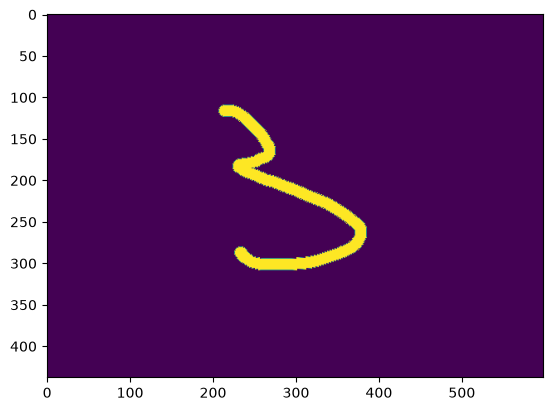

In [6]:
plt.imshow(list_with_imgs[3])

#### Create a very basic evaluation script

At some point, we need the program to check, if it is really doing the correct things. 
We will therefore now think of a very simple dummy function that might be usable for such a task.

Here, we have to think what we have and what we actually want to do:

We want to:
- predict a digit from an image

We will use for training:
- an image of a digit
- the real digit corresponding to this image 

We can therefore see this as a classification problem:
- The digits are the classes (-> 10 classes from 0-9)
- We predict a class from an image
- For evaluation, we need to somehow compare, if the predicted class actually is the real class

In [11]:
# For now, we do not have training samples, only our postal code. How might we classify?
sum_pixels = []
digi_class = []

for digit in list_with_imgs:
    sum_pixels.append(digit.sum())
    if digit.sum() < 1320000:
        digi_class.append(1)
    elif digit.sum() >= 1320000 and digit.sum() < 1350000:
        digi_class.append(2)
    
#How do we evluate?


In [25]:
sum_pixels

[np.uint64(1319958),
 np.uint64(2208867),
 np.uint64(1987790),
 np.uint64(1670711),
 np.uint64(2206936)]

#### Now we will load existing data for training a model that learns how to classify

PyTorch has several datasets for training and testing models stored for you to download.

One very famous dataset is the so called MNIST data, which includes thousands of handwritten images of digits and their correspoding real digits as labels.

This dataset is ideal to train our model, which can then hopefully identify our Paint-written digits.

In [12]:
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

# after importing the necessary package modules, loading the data is as simple as:
train_data = MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

In [13]:
# We can now again look at the data
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [14]:
# in total, the training data contains 60.000 entries
len(train_data)

60000

In [15]:
# How does one entry look like?
print("The type of the first entry is:", type(train_data[0]))
print("The length of the first entry is:", len(train_data[0]))

The type of the first entry is: <class 'tuple'>
The length of the first entry is: 2


In [16]:
# The two entries of the tuple are the image, and the corresponding digit
image, label = train_data[5042]
print("The image has a dimension of:", image.shape)
print("The image contains the digit:", label)

The image has a dimension of: torch.Size([1, 28, 28])
The image contains the digit: 8


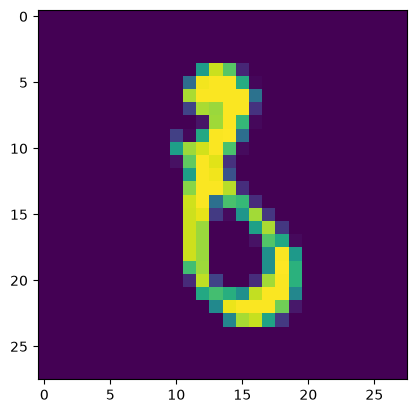

In [17]:
plt.imshow(image[0,:,:])

In [18]:
# One more note regarding data types:

# The image from the MNIST downloader is a "torch.Tensor"
# This is a PyTorch datatype, which is very interchangable with numpy.arrays:
print(type(image))
print(type(image.numpy()))

<class 'torch.Tensor'>
<class 'numpy.ndarray'>


#### This dataset can now be used to formulate a supervised ML task

We will explain the general concept on the board

#### Neural Networks are one option for supervised ML

We will explain te general concept on the board

Explain general concept of fully connected NN -> Matrix Multiplications that are performed

Explain Activation function (Sigmoid vs. ReLU and why most networks use the latter)

Explain Gradient Descent on Loss Function 

Explain CNN and deep learning

Explain SoftMax for our case

Explain Overfitting and regularization

What is Epoch, What is Batch?

What is Backpropagation?

What are Hyperparameter

How is all of this connected to PyTorch?

##### PyTorch is a very powerful package for creating customized Neural Networks easily

All major steps and peaces are implemented and just need to be put together

Ideas of PyTorch:


We will now implement a simple neural network for image classification.

For functioning Neural Networks, we aways need:

- Training and Validation data
- A model
- A loss function 
- An Optimizer that tunes our weights according to the loss function

In [19]:
################################################
################## The Data ####################
################################################

# Training data is available from above: 
train_data = train_data

# We can download the validation data in the same fashion:
val_data = MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

In [20]:
# PyTorch offers another really good advantage: It allows training in batches, 
# which are equally sized "buckets" of training data. 
# Each batch is processed at once and averaged, increasing the training speed but potentially
# resulting in too generalized results

# Loading the data in batches is easy:

# We first import the DataLoader module from torch
from torch.utils.data import DataLoader

# We now create a DataLoader object, which allows separates the data into the "buckets", over which we will iterate for x epochs
train_loader = DataLoader(
    train_data,
    batch_size=64,   # this is equal to the number of training data in each "bucket"
    shuffle=True,    # with shuffle = True, samples are randomly put together into a "bucket" at every epoch. Better generalization.
)

val_loader = DataLoader(
    val_data,
    batch_size=64,
    shuffle=False, # For validation, we can turn shuffle to False, because we do not train the model anymore -> no influence on the model
)

In [21]:
################################################
################## The Model ###################
################################################

import torch
from torch import nn

# We first use a simple fully connected network.
# The input is our image, the output is a vector with 10 entries, 
# each entry has a value corresponding to a digit.
class MNISTClassifier_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Flatten(),               # we start with a 2D tensor with 28x28 -> this flattens it into 1D with [B, 784]
            nn.Linear(28 * 28, 128),    # In the first layer, we go from 784 to 128 in a fully connected fashion
            nn.ReLU(),                  # We use the ReLu() activation function
            nn.Linear(128, 10),         # We use a second fully connected layer to go from 128 dimensions to 10 -> our classes
        )

    def forward(self, x):
        
        network_result = self.network(x) # We call the defined network 
        
        return network_result
        
# After defining the model class, we need to create an object of the model:
model = MNISTClassifier_MLP()

In [51]:
batch_1 = next(iter(train_loader))

In [58]:
print("Images:", batch_1[0].shape)
print("Labels:", batch_1[1].shape)

Images: torch.Size([64, 1, 28, 28])
Labels: torch.Size([64])


In [72]:
# What does every step do?

flatten_img = nn.Flatten()
flatten_result = flatten_img(batch_1[0])

print("Shape:",flatten_result.shape)
print(flatten_result[0,:])

Shape: torch.Size([64, 784])
tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0

In [71]:
hidden_layer = nn.Linear(28 * 28, 128)
h_layer_result = hidden_layer(flatten_result)

print("Shape:", h_layer_result.shape)
print(h_layer_result[0,:])

Shape: torch.Size([64, 128])
tensor([-0.2068, -0.0802,  0.0334, -0.1149, -0.1292, -0.0233, -0.0273, -0.1122,
         0.0011, -0.1871,  0.0164,  0.2608, -0.0802, -0.0306,  0.1595, -0.2185,
         0.0372, -0.0565,  0.0692,  0.0166,  0.2072,  0.1952,  0.1488, -0.0979,
         0.1802, -0.0209, -0.1609, -0.1021,  0.0453, -0.0811, -0.2589, -0.3504,
         0.3720,  0.3583, -0.1236, -0.2796,  0.0732,  0.1934, -0.2051,  0.0580,
         0.0357, -0.1648,  0.4427,  0.3676, -0.0704,  0.1628,  0.2196, -0.1133,
         0.4019,  0.0065, -0.0464,  0.1740, -0.0144,  0.3032,  0.2295,  0.1464,
         0.2135, -0.1365,  0.0050,  0.0713, -0.2252,  0.0822, -0.0514, -0.1569,
        -0.1222, -0.1778,  0.1916,  0.1010, -0.0982,  0.1832, -0.3476, -0.0199,
         0.0154,  0.0598, -0.0783,  0.3724, -0.0624,  0.0569,  0.2272,  0.1136,
         0.3312,  0.0772, -0.2255,  0.0495, -0.1060,  0.0576, -0.2863,  0.2883,
        -0.0887,  0.0399, -0.0842, -0.2017,  0.2385,  0.2438, -0.0535,  0.1777,
        -0.

In [69]:
activation_func = nn.ReLU()
h_layer_relu = activation_func(h_layer_result)

print("Shape:", h_layer_relu.shape)
print(h_layer_relu[0,:])

Shape: torch.Size([64, 128])
tensor([0.4778, 0.0000, 0.0703, 0.1187, 0.0000, 0.2666, 0.0000, 0.2765, 0.0000,
        0.0000, 0.1913, 0.2631, 0.1387, 0.1774, 0.0966, 0.2734, 0.0000, 0.0000,
        0.0000, 0.0967, 0.0196, 0.0000, 0.0000, 0.0000, 0.2853, 0.0000, 0.0000,
        0.0241, 0.0000, 0.0000, 0.1481, 0.0000, 0.0610, 0.0057, 0.1556, 0.0000,
        0.0000, 0.1567, 0.0000, 0.0000, 0.4003, 0.1595, 0.0000, 0.2423, 0.0902,
        0.0000, 0.0238, 0.0000, 0.0000, 0.0000, 0.0000, 0.0979, 0.0000, 0.0000,
        0.1310, 0.3205, 0.0000, 0.0000, 0.0320, 0.0508, 0.1765, 0.0000, 0.0471,
        0.1895, 0.0000, 0.0689, 0.0000, 0.1849, 0.2015, 0.0000, 0.1523, 0.0000,
        0.4334, 0.0000, 0.0376, 0.0471, 0.0000, 0.0000, 0.0474, 0.0335, 0.0000,
        0.1155, 0.0789, 0.1065, 0.0000, 0.0000, 0.0000, 0.0000, 0.1853, 0.4694,
        0.0000, 0.3223, 0.0847, 0.0000, 0.0000, 0.0000, 0.0000, 0.0881, 0.0152,
        0.2477, 0.0000, 0.0000, 0.0495, 0.0000, 0.0000, 0.0000, 0.1802, 0.0000,
        0.0

In [73]:
output_layer = nn.Linear(128,10)
out_layer_result = output_layer(h_layer_relu)

print("Shape:",out_layer_result.shape)
print(out_layer_result[0,:])

Shape: torch.Size([64, 10])
tensor([ 0.1093,  0.1597,  0.1068, -0.0731, -0.0149,  0.0980, -0.0009,  0.1579,
         0.0556, -0.0488], grad_fn=<SelectBackward0>)


In [ ]:
flatten_img = nn.Flatten()
hidden_layer = nn.Linear(28 * 28, 128)
activation_func = nn.ReLU()
output_layer = nn.Linear(128,10)

# This needs to be called in the forward() function of your newly defined neural network class
flatten_result = flatten_img(batch_1[0])
h_layer_result = hidden_layer(flatten_result)
h_layer_relu = activation_func(h_layer_result)
out_layer_result = output_layer(h_layer_relu)

print("Shape:",out_layer_result.shape)
print(out_layer_result[0,:])

Shape: torch.Size([64, 10])
tensor([ 0.1273, -0.0695,  0.0319,  0.1056, -0.0878, -0.1850, -0.0687, -0.0780,
         0.0999,  0.0430], grad_fn=<SelectBackward0>)


In [ ]:
flatten_img = nn.Flatten()
hidden_layer = nn.Linear(28 * 28, 128)
activation_func = nn.ReLU()
output_layer = nn.Linear(128,10)

# This needs to be called in the forward() function of your newly defined neural network class
out_layer_result = output_layer(activation_func(hidden_layer(flatten_img(batch_1[0]))))

print("Shape:",out_layer_result.shape)
print(out_layer_result[0,:])

Shape: torch.Size([64, 10])
tensor([ 0.0109,  0.0867, -0.0194,  0.0612, -0.0982, -0.0869,  0.1845, -0.1168,
         0.1087,  0.0844], grad_fn=<SelectBackward0>)


In [ ]:
network = nn.Sequential(
    nn.Flatten(),               # we start with a 2D tensor with 28x28 -> this flattens it into 1D with [B, 784]
    nn.Linear(28 * 28, 128),    # In the first layer, we go from 784 to 128 in a fully connected fashion
    nn.ReLU(),                  # We use the ReLu() activation function
    nn.Linear(128, 10),         # We use a second fully connected layer to go from 128 dimensions to 10 -> our classes
)

# This needs to be called in the forward() function of your newly defined neural network class
pred = network(batch_1[0])     

print("Shape:",pred.shape)
print(pred[0,:])

Shape: torch.Size([64, 10])
tensor([ 0.1209,  0.0728, -0.0025,  0.1241, -0.0175,  0.1585,  0.0290, -0.1833,
        -0.0961, -0.1037], grad_fn=<SelectBackward0>)


In [18]:
# Lets have a look at the total number of model parameters.
# These are the total number of parameters.
total_params = sum(parameter.numel() for parameter in model.parameters())
print(f"Total parameters: {total_params:,}")

# To have a look at only the trainable parameters, we do:
trainable_params = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)
print(f"Trainable parameters: {trainable_params:,}")

#This comes from:
#Linear(784 → 128): 784 × 128 + 128 = 100,480
#Linear(128 → 10):  128 × 10 + 10   =   1,290
#Total:                               101,770

Total parameters: 101,770
Trainable parameters: 101,770


In [ ]:
################################################
############## The Loss Function ###############
################################################

# We can either implement the loss function of choice ourselves
def our_cross_entropy(logits_output, targets):
    digits_to_proba = torch.log_softmax(logits_output, dim=-1) #Apply a softmax to our logits
    batch_indices = torch.arange(logits_output.shape[0])
    
    correct_probabilities = digits_to_proba[batch_indices, targets]
    losses = -torch.log(correct_probabilities)
    return losses.mean()


# Or we can use an existing PyTorch function for it
loss_function = nn.CrossEntropyLoss()

In [23]:
################################################
################ The Optimizer #################
################################################

# Different optimizers are available in PyTorch
# We choose to use Adam. 
# We therefore need to give the model parameters and the learning rate 'lr'.

# !!! IMPORTANT !!!
# After calling this, do not initialize your model again by accident

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [24]:
################################################
############## Training the Model ##############
################################################

# Now everything is defined, lets put it together in a loop that trains all samples for a given number of epochs.
# !!! IMPORTANT !!!
# During training, we always need 1. optimizer.zero_grad() -> 2. loss.backward() -> 3. optimizer.step()
# This corresponds to 
# 1. Set the gradients from the previous batch to 0 before calculating gradients for the current batch
# 2. Calculate the gradients via backpropagation and add them to each tuneable parameters .grad value
# 3. Update the models training parameters according to the gradients (and the fixed learning rate of te optimizer)
# The sequencing is important here, because you need to make sure to calculate the gradients on empty .grad values. 

# Train
epochs = 5

for epoch in range(epochs):
    model.train()                       # turn on training mode
    total_loss = 0.0                    # initialize loss for display purposes

    for images, labels in train_loader: # iterate over every batch in the train_loader. The larger the batch size, the lower the number of iterations

        optimizer.zero_grad()           # Set the gradients from the previous batch to 0 before calculating gradients for the current batch

        logits = model(images)          # Call the model. Input: images (see forward function of model); Output: Vector with 10 entries
        
        loss = loss_function(logits,    # Call the loss function. nn.CrossEntropyLoss() takes predictions first, true values second.
                             labels)

        loss.backward()                 # Calculate the gradients via backpropagation
        optimizer.step()                # Update the models training parameters according to the gradients

        total_loss += loss.item()       # Update the loss with the loss from this batch. Displaying purposes only

    average_loss = total_loss / len(train_loader) # after every batch of an epoch is run through, we average the summarized loss
    print(f"Epoch {epoch + 1}/{epochs}, loss: {average_loss:.4f}") # We print the losses for each epoch. We want them to go down

Epoch 1/5, loss: 0.3422
Epoch 2/5, loss: 0.1588
Epoch 3/5, loss: 0.1118
Epoch 4/5, loss: 0.0839
Epoch 5/5, loss: 0.0673


In [22]:
################################################
############# Evaluating the Model #############
################################################

model.eval() # turn on evaluation mode
correct = 0  # track the number of correctly assigned digits
total = 0    # # track the total number of samples 

with torch.no_grad():
    for images, labels in val_loader:
        
        images = images                                 # Maybe add the .device()
        labels = labels

        logits = model(images)                          # run the trained model on the validation data
        
        predictions = logits.argmax(dim=1)              # we do not necessarily need to calculate the loss for validation.
                                                        # We can also simply check, if the correct ddigit was predicted.
                                                        # Thereto, we treat the highst value of the ouput vector as the prediction,
                                                        # find its position and treat this position as the digit label 
                                                        # E.g., the highest prediction value is at position 5 -> the image shows a 5

        correct += (predictions == labels).sum().item() # We now check, how many of the digits of the batch are correctly predicted
        total += labels.size(0)                         # and save the size of the batch

accuracy = correct / total                              # With this, we can calculate the proportion of correctly predicted digits
print(f"Test accuracy: {accuracy:.2%}")

Test accuracy: 97.49%


## EXERCISE 
### Hyperparameter might have an influence on the results. 

Please play around with the hyperparameters (number of hidden layers, batch size, learning rate, epochs) and keep track different results:
- How long did model training take?
- How is the performance on Train and Validation set?
- Also, combine train and validation into the same epoch-loop and track both losses for every epoch. This will help to identify overfitting.

.
.
.

In [ ]:
# Save the learned parameters
torch.save(model.state_dict(), "mnist_model.pth")

## EXERCISE 
### Although this already works very well, Convolutional Neural Networks are often the more natural choice for images

Please adapt the model from above into a model that uses PyTorchs Conv2D function (https://docs.pytorch.org/docs/2.13/generated/torch.nn.Conv2d.html), i.e. a 2D-filter that shifts across the image.

- in_channels is thereby the number of channels of your image (greyscale images have only a single channel), out_channels the number of convolutional kernels you want to use. 
- kernel_size refers to the size of your filter, i.e. the number of neighbours that are taken into account around the observed pixel.
- stride and padding are used to steer the width and height of the resulting image (see https://hannibunny.github.io/mlbook/neuralnetworks/convolutionDemos.html for an animation).

Pooling (e.g., MaxPool2d) can also be used to reduce the size of the results of the different layers.

In [ ]:
import torch
from torch import nn

class MNISTClassifier_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.first_conv = nn.Sequential(              
            nn.Conv2d(1, 32, (3,3), stride=1, padding=1),    
            nn.ReLU(),
            nn.MaxPool2d((2,2)),
            )
        self.second_conv = nn.Sequential(              
            nn.Conv2d(32, 64, (3,3), stride=1, padding=1),    
            nn.ReLU(),
            nn.MaxPool2d((2,2)),            
        )
        self.conv_to_output = nn.Sequential(
            nn.Conv2d(32, 1, (3,3), stride=1, padding=1),    
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(int(((28 * 28)/4)/4), 10),    
        )

    def forward(self, x):
        
        first_layer = self.first_conv(x)
        second_layer = self.second_conv(first_layer)
        network_result = self.conv_to_output(second_layer) # We call the defined network 
        
        return network_result
    
    
# After defining the model class, we need to create an object of the model:
model = MNISTClassifier_CNN()

In [199]:
import torch
from torch import nn

class MNISTClassifier_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.first_conv = nn.Sequential(              
            nn.Conv2d(1, 32, (3,3), stride=1, padding=1),    
            nn.ReLU(),
            nn.MaxPool2d((2,2)),
            )
        self.second_conv = nn.Sequential(              
            nn.Conv2d(32, 64, (3,3), stride=1, padding=1),    
            nn.ReLU(),
            nn.MaxPool2d((2,2)),            
        )
        self.conv_to_output = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        
        first_layer = self.first_conv(x)
        second_layer = self.second_conv(first_layer)
        network_result = self.conv_to_output(second_layer) # We call the defined network 
        
        return network_result
    
# After defining the model class, we need to create an object of the model:
model = MNISTClassifier_CNN()

In [200]:
total_params = sum(parameter.numel() for parameter in model.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 421,642


In [ ]:
# Define Optimizer and loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_function = nn.CrossEntropyLoss()

# Train
epochs = 5

for epoch in range(epochs):
    
    print(f"Start Epoch {epoch+1}")
    
    # Training
    # turn on training mode
    model.train()            
    # initialize loss for measuring its development over the epochs           
    total_loss = 0.0                    

    for images, labels in train_loader: 
        
        # Set the gradients from the previous batch to 0 before calculating gradients for the current batch
        optimizer.zero_grad()         
          
        # Call the model. Input: images (see forward function of model); Output: Vector with 10 entries
        logits = model(images) 
                 
        # Call the loss function. nn.CrossEntropyLoss() takes predictions first, true values second.
        loss = loss_function(logits,labels)    
        
        # Calculate the gradients via backpropagation                     
        loss.backward()     
        # Update the models training parameters according to the gradients            
        optimizer.step()                
        
        # Update the loss with the loss from this batch. Displaying purposes only
        total_loss += loss.item()       

    # Average the loss for this epoch
    average_loss = total_loss / len(train_loader) 

    ################################################################################################
    ################################################################################################
    
     # Evaluation
    model.eval() # turn on evaluation mode
    correct = 0  # track the number of correctly assigned digits
    total = 0    # # track the total number of samples 
    validation_loss = 0.0 

    all_pred = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            
            images = images                                 # Maybe add the .device()
            labels = labels
            
            logits = model(images)                          # run the trained model on the validation data
            
            predictions = logits.argmax(dim=1)   
            
            loss = loss_function(logits,labels)
            validation_loss += loss.item()  
                        
            correct += (predictions == labels).sum().item() # Save correctly predicted digits of the batch 
            total += labels.size(0)                         # Save total size of the batch

    # Calculate average loss per epoch for validation samples
    average_val_loss = validation_loss / len(val_loader)
    # Calculate the proportion of correctly predicted digits 
    accuracy = correct / total     
    
    # Print the loss of each epoch. We want them to go down
    print(f"Epoch {epoch + 1}/{epochs}, training loss: {average_loss:.4f}, validation loss: {average_val_loss:.4f}, validation accuracy: {accuracy:.2%}") 
    

### Evaluation

To thouroughly evaluate the results, we often use a confusion matrix (https://en.wikipedia.org/wiki/Confusion_matrix). It compares predction vs. real world target classes and allows us to derive a number of important values:

- True Positives (TP): Correctly predicted class values of the investigated class
- True Negatives (TN): Correctly predicted as one of the remaining classes
- False Positives (FP): Predicted as the investigated classes, although, in reality, the sample belongs to one of the remaining classes 
- False Negatives (FN): Predicted as one of the remaining classes, although, in reality, the sample belongs to the investigated class 

From these values, several indices are often derived:
- Recall: TP/(TP+FN)
- Precision: TP/(TP+FP)
- Overall Accuracy: (TP+TN) / (TP+TN+FN+FP)
- F1-Score: 2* (Recall * Precision) / (Recall + Precision)

When judging a model, it is important to look at multiple values together, using only Recall or Precision will lead to wrong assumptions or statements.

The sklearn.metrics module includes a function for the confusion matrix and all of these indices, making it easy to calculate them. 

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score

# The confusion matrix
print(confusion_matrix(torch.concat(all_labels), torch.concat(all_pred)))

In [ ]:
# Recall, Precision, Overall Accuracy

print(precision_score(torch.concat(all_labels), torch.concat(all_pred), average=None)) #TP/(TP+FP)
print(recall_score(torch.concat(all_labels), torch.concat(all_pred), average=None)) #TP/(TP+FN)
print(accuracy_score(torch.concat(all_labels), torch.concat(all_pred))) #(TP+TN) / (TP+TN+FN+FP)

For our real world data, we can derive additional valuable information from the confusion matrix: which digits are most likely to be wrongly assigned in our postal code identification? What does that mean for us? 

Additionally, the postal codes are finite. Can this be used for inference?

#### Now we apply this model to our real world data. 

We already loaded the images, but they have a different shape and datatype (remember, quite big 2D images as a numpy array)

In [25]:
# We adapt the loop to automatically give us numpys in the wanted dimensions:
def load_img(path):
    image = np.asarray(Image.open(path).convert("L"))
    pixels = np.array(image, copy=True)
    
    mask_255 = np.where(pixels == 255)
    mask_0 = np.where(pixels == 0)
    pixels[mask_255] = 0
    pixels[mask_0] = 255
    
    xr_image = xr.DataArray(
    pixels,
    dims=("y", "x"),
    name="brightness",
    )
    
    # image has dimensions ("y", "x")
    xr_image = xr_image.assign_coords(
        y=np.arange(xr_image.sizes["y"]),
        x=np.arange(xr_image.sizes["x"]),
    )

    target_y = np.linspace(xr_image.y.min().item(), xr_image.y.max().item(), 28)
    target_x = np.linspace(xr_image.x.min().item(), xr_image.x.max().item(), 28)

    resized = xr_image.interp(
        y=target_y,
        x=target_x,
        method="cubic",
    )

    return resized

# Now, we need a list of all images to load.
# We use os.listdir to list all files in the given directory:
init_path = "M:/AI4Science/Symposium/2026/Workshops/Material_Workshop_1/"
list_of_pngs = os.listdir(init_path)
print(list_of_pngs)

# the loop itself
imgs_mnist_size = []
for png in list_of_pngs:
    if png.endswith(".png"):
        
        numpy_img = np.array(load_img(init_path + png))
        numpy_img = np.float32(numpy_img)
        
        # Convert 0–255 values to 0–1
        numpy_img /= numpy_img.max()
        tensor_img = torch.from_numpy(numpy_img)
        # Grayscale image: [28, 28] -> [1, 1, 28, 28]
        tensor_img = tensor_img.unsqueeze(0).unsqueeze(0)
        
        imgs_mnist_size.append(tensor_img)

['Postal_code_1.png', 'Postal_code_3.png', 'Postal_code_3_end.png', 'Postal_code_3_v2.png', 'Postal_code_5.png', 'Präsentation.pptx', 'Thumbs.db', '~$Präsentation.pptx']


In [140]:
# lets look at the shape of one tensor:
imgs_mnist_size[0].shape

# -> looks good, since (B,C,W,H) is all there. Lets try to use it as input!

torch.Size([1, 1, 28, 28])

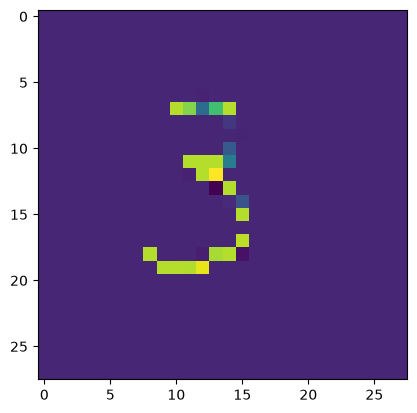

In [192]:
plt.imshow(imgs_mnist_size[2][0,0,:,:])

In [34]:
for dig in imgs_mnist_size:
    with torch.no_grad():
        logits = model(dig)  
        predictions = logits.argmax(dim=1)
        print(predictions[0])

tensor(1)
tensor(5)
tensor(5)
tensor(5)
tensor(5)


In [46]:
print("Probabilities for the last digit:", torch.softmax(logits[0], dim=0)*100)

Probabilities for the last digit: tensor([7.0685e-02, 4.7312e-01, 2.8737e+00, 5.9443e+00, 1.1978e-02, 8.7968e+01,
        9.5943e-01, 1.5460e-02, 1.5978e+00, 8.5363e-02])


In my case: 2/5 correct, so mediocre performance :(

In [203]:
# With the updated CNN:

for dig in imgs_mnist_size:
    logits = model(dig)  
    predictions = logits.argmax(dim=1)
    print(predictions[0])

tensor(1)
tensor(3)
tensor(3)
tensor(5)
tensor(5)


Much better!! 
4/5 correct.